# Ôn tập giữa kỳ


In [ ]:
# import library...
# ...

## ĐỀ BÀI

Hệ thống giám sát rủi ro dựa trên hành vi (The Behavior Risk Factor Surveilance System - BRFSS) là một cuộc khảo sát qua điện thoại hàng năm với 350.000 người ở Hoa Kỳ. Như tên gọi của nó, BRFSS được thiết kế để xác định các yếu tố nguy cơ ở người trưởng thành và báo cáo các xu hướng sức khỏe mớ. Ví dụ, người trả lời được hỏi về chế độ ăn uống và hoạt động thể chất hàng tuần, tình trạng HIV/AIDS, khả năng sử dụng thuốc lá và thậm chí cả mức độ chi trả dịch vụ chăm sóc sức khỏe của họ. 

Bộ dữ liệu **brfss_2000** chứa thông tin khảo sát năm 2000, với hơn 200 thông tin. Trong bộ dữ liệu này, ta chỉ khảo sát một số thông tin sau:
-	genhlth: người khảo sát tự đánh giá sức khỏe (excellent, very good, good, fair or poor)
-	exerany: cho biết có hoạt động thể chất nào trong tháng gần nhất hay không, có (1), không (0)
-	hlthplan: có bảo hiểm (1) hay không (0)
-	smoke100: tổng số điếu thuốc đã hút ít nhất
-	height: chiều cao (inches)
-	weight: cân nặng (pounds)
-	wtdesire:  cân nặng mong muốn(pounds)
-	age: tuổi
-	gender: giới tính: nam(m), nữ(f)


### Câu 1:

Đọc hai bộ dữ liệu trên và cho biết mỗi bộ dữ liệu có kích thước bao nhiêu dòng, bao nhiêu cột?

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(filepath_or_buffer='brfss_2000.csv', header=0, delimiter=',', encoding='utf-8')
df.shape

(20000, 9)

### Câu 2

a, Tính tỷ lệ nam nữ

b, Trong số những người tập thể thao, tỷ lệ những người tự đánh giá có sức khỏe kém là bao nhiêu?

In [7]:
p = df['gender'].value_counts() / df.shape[0] * 100
p

df[(df['exerany'] == 1) & (df['genhlth'] == 'poor')]['genhlth'].count() / 
                                                (df['exerany'] == 1).count() * 100

1.465

### Câu 3

a, Đổi đơn vị chiều cao từ inches sang centimet, đơn vị cân nặng từ pound sang kg.

b, Tính tỷ lệ những người muốn giảm cân.

In [24]:
df['height'] = df['height'] * 2.54
df['weight'] = df['weight'] * 0.45359237

df['wtdesire'] = df['wtdesire'] * 0.45359237
print(df[df['weight'] - df['wtdesire'] > 0].shape[0] / df.shape[0] * 100)
df

63.82


,exerany,hlthplan,smoke100,height,weight,wtdesire,age,gender,genhlth
0,0,1,0,177.80,79.378665,79.378665,77,m,good
1,0,1,1,162.56,56.699046,52.163123,33,f,good
2,1,1,1,152.40,47.627199,47.627199,49,f,good
3,1,1,0,167.64,59.874193,56.245454,42,f,good
4,0,1,0,154.94,68.038855,58.967008,55,f,very good
...,...,...,...,...,...,...,...,...,...
19995,1,1,0,167.64,97.522360,63.502932,23,f,good
19996,0,1,0,185.42,90.718474,83.914588,35,m,excellent
19997,0,1,0,165.10,97.975952,68.038855,57,f,poor
19998,1,1,0,170.18,74.842741,74.842741,81,f,good


### Câu 4:

a, Theo bạn trong các thuộc tính trên, thuộc tính nào có phân phối chuẩn. Vẽ hình minh họa

b, Vẽ đồ thị boxplot so sánh cân nặng của những người có tập thể dục

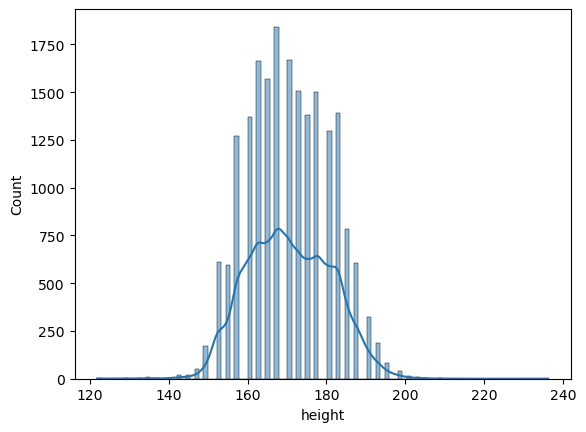

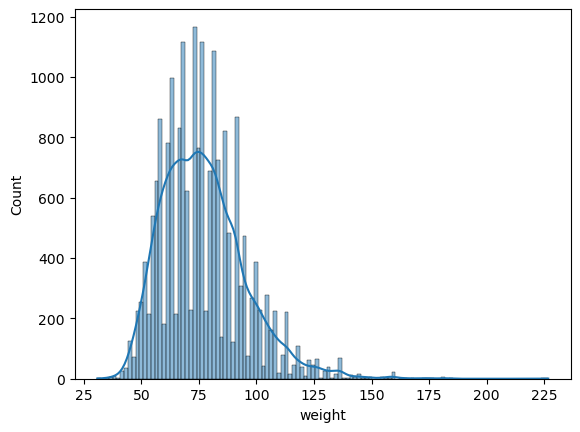

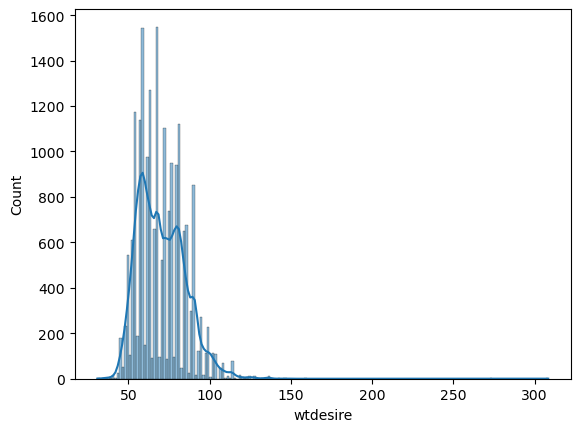

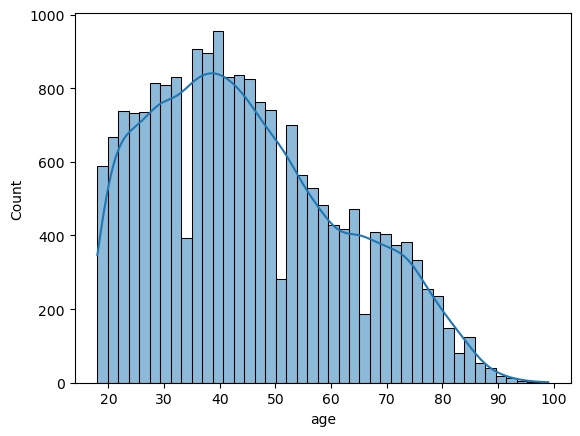

<Axes: ylabel='weight'>

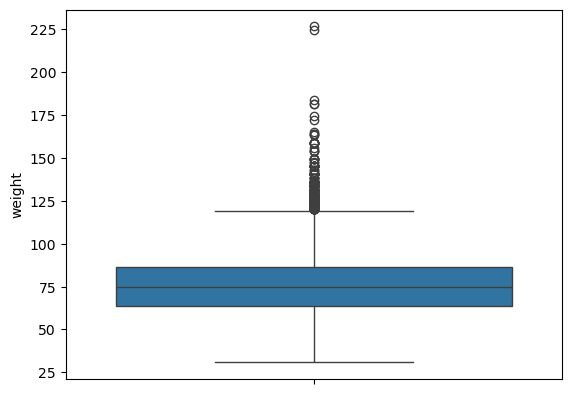

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

df.describe()
#exerany	hlthplan	smoke100	height	weight	wtdesire	age
for i in df.describe().columns.values:
    if(len(df[i].value_counts().values) > 30):
        sns.histplot(data=df[i], kde=True)
        plt.show()

sns.boxplot(data=df[df['exerany'] == 1]['weight'])


### Câu 5

Phân bố tuổi tác trong mẫu: Hãy mô tả phân bố tuổi của người tham gia khảo sát. Tuổi trung bình, độ lệch chuẩn, và các phân vị 25%, 50%, 75% là bao nhiêu?



In [52]:
df['age'].describe()

count    20000.000000
mean        45.068250
std         17.192689
min         18.000000
25%         31.000000
50%         43.000000
75%         57.000000
max         99.000000
Name: age, dtype: float64

### Câu 6

Tỉ lệ người hút thuốc: Tính tỉ lệ phần trăm người tham gia khảo sát hiện đang hút thuốc lá. Liệu có sự khác biệt đáng kể về tỉ lệ này giữa các nhóm tuổi khác nhau không?



47.205000000000005


C:\Users\QUANG MINH\AppData\Local\Temp\ipykernel_27416\991592319.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  d = df[df['smoke100'] > 0].groupby(by='age_group')['smoke100'].count() / df.groupby(by='age_group')['smoke100'].count() * 100


<Axes: xlabel='age_group', ylabel='smoke100'>

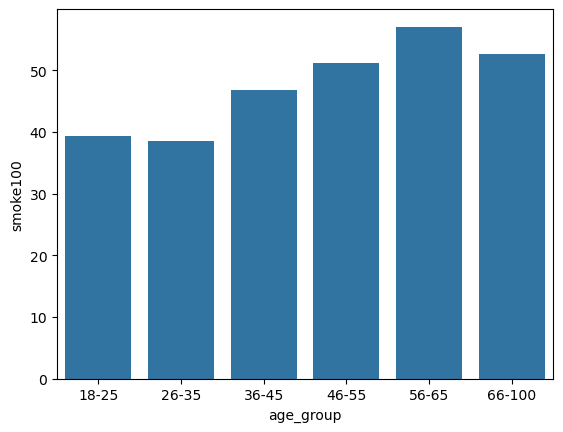

In [79]:
print(df[df['smoke100'] > 0].shape[0] / df.shape[0] * 100)

age_bins = [18, 25, 35, 45, 55, 65, 100]  # Các khoảng độ tuổi
age_labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '66-100']  # Các tên nhóm
df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels, right=False)
df

d = df[df['smoke100'] > 0].groupby(by='age_group')['smoke100'].count() / df.groupby(by='age_group')['smoke100'].count() * 100
d
sns.barplot(data=d)

### Câu 7

BMI trung bình theo giới tính: Tính chỉ số BMI trung bình cho nam và nữ trong mẫu. 



In [81]:
df['BMI'] = df['weight'] / (df['height'] / 100) ** 2
df

,exerany,hlthplan,smoke100,height,weight,wtdesire,age,gender,genhlth,age_group,BMI
0,0,1,0,177.80,79.378665,79.378665,77,m,good,66-100,25.109628
1,0,1,1,162.56,56.699046,52.163123,33,f,good,26-35,21.455981
2,1,1,1,152.40,47.627199,47.627199,49,f,good,46-55,20.506196
3,1,1,0,167.64,59.874193,56.245454,42,f,good,36-45,21.305139
4,0,1,0,154.94,68.038855,58.967008,55,f,very good,56-65,28.341961
...,...,...,...,...,...,...,...,...,...,...,...
19995,1,1,0,167.64,97.522360,63.502932,23,f,good,18-25,34.701552
19996,0,1,0,185.42,90.718474,83.914588,35,m,excellent,36-45,26.386548
19997,0,1,0,165.10,97.975952,68.038855,57,f,poor,56-65,35.943912
19998,1,1,0,170.18,74.842741,74.842741,81,f,good,66-100,25.842388


### câu 8

Phân tích tỉ lệ bệnh béo phì: Sử dụng các tiêu chuẩn của CDC về chỉ số BMI để phân loại người tham gia vào nhóm béo phì. Tính tỉ lệ béo phì theo giới tính và độ tuổi. 

In [92]:
value = [0, 18.5, 25, 30, 35, 40, np.inf]
label = ['Gầy', 'Bình thường', 'Thừa cân', 'Béo phì độ I', 'Béo phì độ II', 'Béo phì độ III']
df['CDC béo phì'] = pd.cut(x=df['BMI'], bins=value, labels=label, right=False)

bp = df['CDC béo phì'].isin(['Béo phì độ I', 'Béo phì độ II', 'Béo phì độ III'])
df[bp][['gender', 'age_group']].value_counts() / df[['gender', 'age_group']].value_counts() * 100

gender  age_group
f       18-25        10.504549
        26-35        16.408204
        36-45        19.232485
        46-55        21.385042
        56-65        23.970944
        66-100       18.679051
m       18-25        11.611785
        26-35        18.615385
        36-45        23.189734
        46-55        25.183099
        56-65        23.339318
        66-100       15.423242
Name: count, dtype: float64

---